<a href="https://colab.research.google.com/github/Arunya-123/Titanic_dataset/blob/main/Titanic_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.weightstats import ztest

In [ ]:
df= pd.read_csv("/content/titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# rows and columns are in the dataset
df.shape

(891, 12)

dataset contain both qualitative and quaditative data.

presense of missing values in Age and Cabin columns which needs to be handeled properly.

whole columns name needs to be change into lowercase.

---

In [ ]:
df.rename(columns={"SibSp":"sibsp", "Survived":"survived","Pclass":"pclass","Sex":"sex","SibSb":"sibsb","Parch":"parch","Fare":"fare","Cabin":"cabin","Embarked":"embarked","Age":"age"}, inplace=True)

In [ ]:
#names of all the columns
df.columns

Index(['PassengerId', 'survived', 'pclass', 'Name', 'sex', 'age', 'sibsp',
       'parch', 'Ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

dataset contain above listed columns,  columns such as PassengerId, Name and Ticket number shouldn't be related to the survival probability. So these columns can be droped.

---



In [ ]:
df.drop(["PassengerId","Name"	,	"Ticket"],axis=1,inplace=True)

In [ ]:
# duplicate records, null values
def preprocessing (data):
  print(f"duplicates counts: {df.duplicated().sum()}")
  print(f"nullvalue  counts:\n{df.isna().sum()}")

preprocessing(df)

duplicates counts: 107
nullvalue  counts:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
cabin       687
embarked      2
dtype: int64


In [ ]:
df.isna().mean()*100

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
cabin,77.104377
embarked,0.224467


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   cabin     204 non-null    object 
 8   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


from nall value analysis age , cabin, embarked columns contain missing values and cabin column contain 77 percentage of null value.

In [ ]:
# unique values in categorical columns
columns=["sex","pclass", "embarked","survived", "sibsp","parch"]
for i in columns:
  print(f" {i} : {pd.unique(df[i])}")


 sex : ['male' 'female']
 pclass : [3 1 2]
 embarked : ['S' 'C' 'Q' nan]
 survived : [0 1]
 sibsp : [1 0 3 4 2 5 8]
 parch : [0 1 2 5 3 4 6]


from analysing unique values in listed columns of  ["sex","pclass", "embarked","survived", "sibsp","parch"] the

sex  have male and female category , passenger class have 3 classes, embarked listed as S- Southampton, C = Cherbourg, Q = Queenstown
survived have yes and no category, siblings or spouse  counted from 0 t0 8 range, parents or children along with counted from 0 to 6






In [ ]:

for i in columns:
  print(f"{i} : {df[i].value_counts()}\n")

sex : sex
male      577
female    314
Name: count, dtype: int64

pclass : pclass
3    491
1    216
2    184
Name: count, dtype: int64

embarked : embarked
S    644
C    168
Q     77
Name: count, dtype: int64

survived : survived
0    549
1    342
Name: count, dtype: int64

sibsp : sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

parch : parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64



In [ ]:
#C = Cherbourg, Q = Queenstown , S = Southampton,

df.loc[df["embarked"]=="C","embarked"]="Cherbourg"

df.loc[df["embarked"]=="Q","embarked"]="Queenstown"
df.loc[df["embarked"]=="S","embarked"]="Southampton"

In [ ]:
df["embarked"]

,embarked
0,Southampton
1,Cherbourg
2,Southampton
3,Southampton
4,Southampton
...,...
886,Southampton
887,Southampton
888,Southampton
889,Cherbourg


embarked columns values are replace into is orginal name for better understanding.




In [ ]:
# statistical summary of the numerical columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


average passengers age is 29.7, survived rate is 38%

In [ ]:
# Passenger Demographics


Text(0, 0.5, 'Passengers Value Count ')

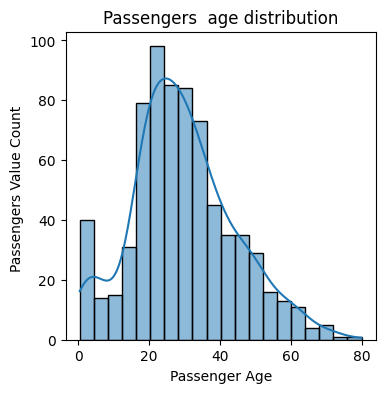

In [106]:
# distribution of passenger ages

plt.figure(figsize=(4,4))
sns.histplot(df["age"], kde=True)
plt.title("Passengers  age distribution")
plt.xlabel("Passenger Age")
plt.ylabel("Passengers Value Count ")

age distribution shows a skewed distribution with a right tail , the tail may represent the presanse of outliers  in age.


Text(0, 0.5, 'Passengers Age')

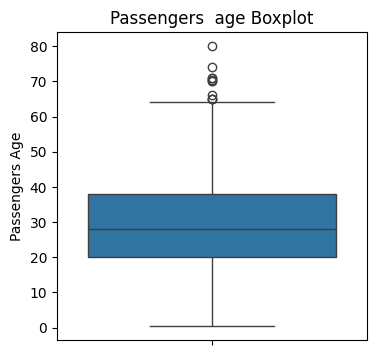

In [ ]:
plt.figure(figsize=(4,4))
sns.boxplot(df["age"])
plt.title("Passengers  age Boxplot")
plt.ylabel("Passengers Age")

from the boxplot of age data clear that the presanse of outliers,  after age of 60 outliers lies in the data.

In [ ]:
df.fillna({"age":df["age"].median(),"embarked":df["embarked"].mode()[0],},inplace=True)

Text(0, 0.5, 'Number of Passengers')

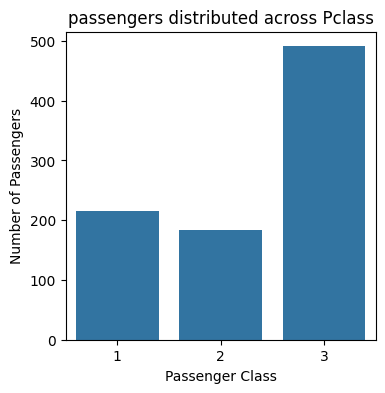

In [ ]:
# passengers distributed across the different passenger classes (Pclass)


plt.figure(figsize=(4,4))
sns.countplot(data=df, x="pclass")

plt.title("passengers distributed across Pclass")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

Distribution of passenger across different classes , third class have above 400 passangers compare to other class. second class thave less passenger count.


Text(0.5, 0, 'Number of parents/child')

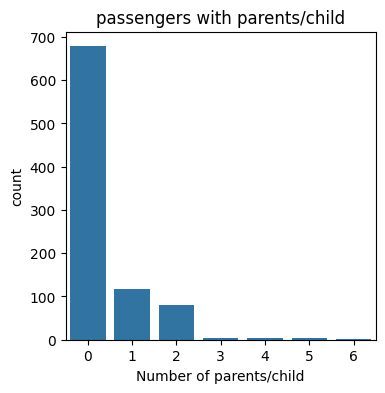

In [ ]:

# passengers had parents/children (Parch)
plt.figure(figsize=(4,4))
sns.countplot(data=df, x=df["parch"])
plt.title("passengers with parents/child")
plt.ylabel("count")
plt.xlabel("Number of parents/child")

Text(0.5, 0, 'Number of siblings/spouses')

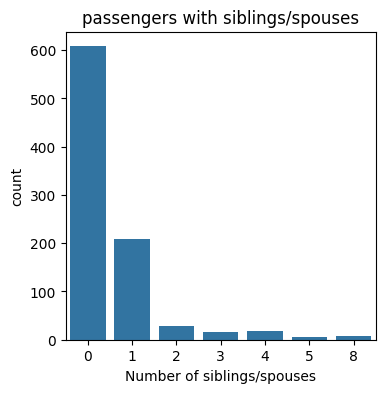

In [ ]:
#passengers had siblings/spouses (SibSp)

plt.figure(figsize=(4,4))
sns.countplot(data=df, x=df["sibsp"])
plt.title("passengers with siblings/spouses")
plt.ylabel("count")
plt.xlabel("Number of siblings/spouses")

In [ ]:
#passengers were traveling alone
df[(df['parch']==0) & (df['sibsp']==0)]

,survived,pclass,sex,age,sibsp,parch,fare,cabin,embarked
2,1,3,female,26.0,0,0,7.9250,NaN,Southampton
4,0,3,male,35.0,0,0,8.0500,NaN,Southampton
5,0,3,male,NaN,0,0,8.4583,NaN,Queenstown
6,0,1,male,54.0,0,0,51.8625,E46,Southampton
11,1,1,female,58.0,0,0,26.5500,C103,Southampton
...,...,...,...,...,...,...,...,...,...
884,0,3,male,25.0,0,0,7.0500,NaN,Southampton
886,0,2,male,27.0,0,0,13.0000,NaN,Southampton
887,1,1,female,19.0,0,0,30.0000,B42,Southampton
889,1,1,male,26.0,0,0,30.0000,C148,Cherbourg


from above distributions  clear that 537 passengers are come along.

Text(0.5, 0, 'Gender')

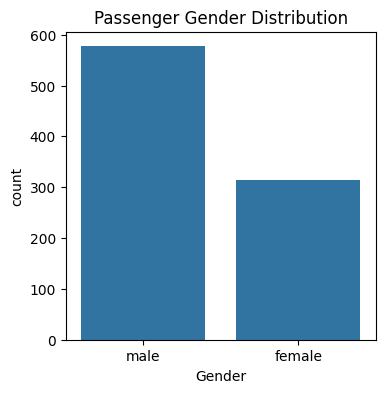

In [107]:
#passengers gender distribution
plt.figure(figsize=(4,4))
sns.countplot(data=df, x="sex")
plt.title("Passenger Gender Distribution")
plt.ylabel("count")
plt.xlabel("Gender")


from passengers gender distribution males have more count than females



Text(0.5, 0, 'Survived')

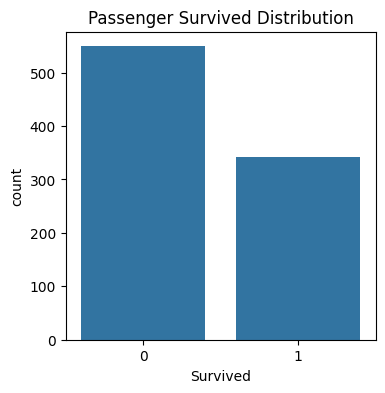

In [ ]:
#passengers survived distribution
plt.figure(figsize=(4,4))
sns.countplot(data=df, x="survived")
plt.title("Passenger Survived Distribution")
plt.ylabel("count")
plt.xlabel("Survived")

out of 891 passengers data 38% people were survived, among the rate passengers survived count is less.

Text(0.5, 0, 'Survived')

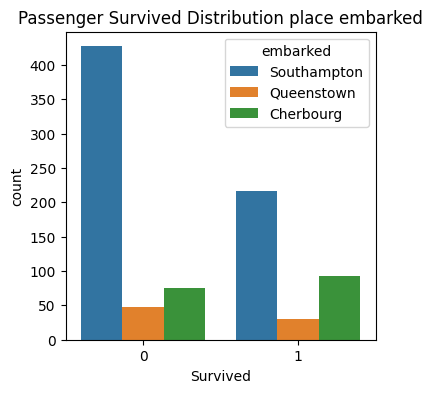

In [ ]:
# embarked passengers survived distribution
plt.figure(figsize=(4,4))
sns.countplot(data=df, x="survived",hue= "embarked")
plt.title("Passenger Survived Distribution place embarked")
plt.ylabel("count")
plt.xlabel("Survived")

Text(0.5, 0, 'Survived')

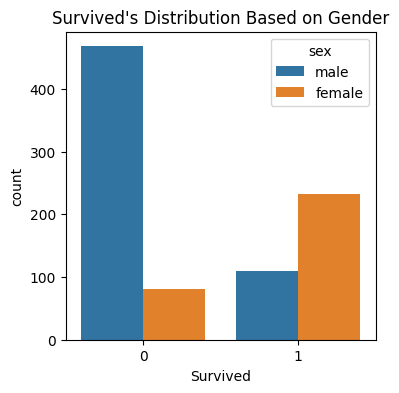

In [ ]:
plt.figure(figsize=(4,4))
sns.countplot(x='survived', data=df,hue = 'sex')
plt.title("Survived's Distribution Based on Gender")
plt.ylabel("count")
plt.xlabel("Survived")

Text(0.5, 0, 'pclass')

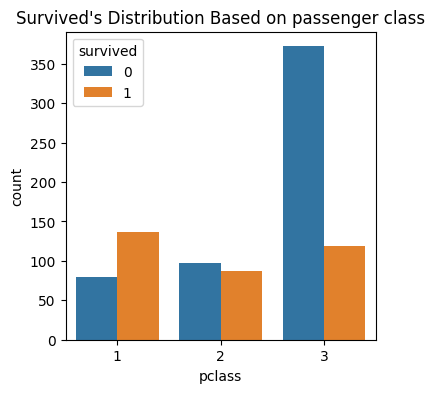

In [ ]:
plt.figure(figsize=(4,4))
sns.countplot(x='pclass', data=df,hue = 'survived')
plt.title("Survived's Distribution Based on passenger class")
plt.ylabel("count")
plt.xlabel("pclass")

Text(0.5, 0, 'pclass')

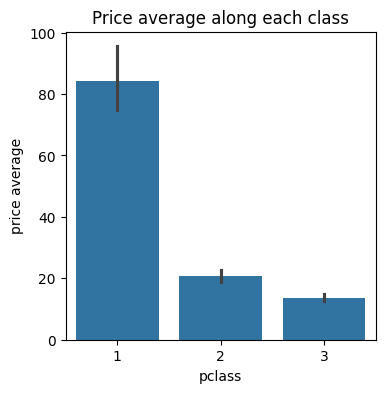

In [ ]:
# price average for each passenger class
plt.figure(figsize=(4,4))
sns.barplot(y = "fare",x = "pclass",data = df)
plt.title("Price average along each class")
plt.ylabel("price average")
plt.xlabel("pclass")

average ticket charge of each passenger class, first class have high ticket chrage.

Text(0.5, 0, 'pclass')

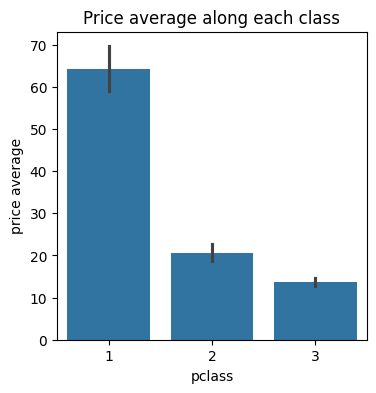

In [ ]:
# price rate for each passenger class less thsn 200
plt.figure(figsize=(4,4))
sns.barplot(y = "fare",x = "pclass",data = df[df["fare"] < 200])
plt.title("Price average along each class")
plt.ylabel("price average")
plt.xlabel("pclass")

In [ ]:
df.groupby('survived').describe()["age"]


,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


In [104]:
df.groupby(['survived','sex'])['survived'].count()

survived  sex   
0         female     81
          male      468
1         female    233
          male      109
Name: survived, dtype: int64

In [105]:
df.groupby(['survived','pclass'])['survived'].count()

survived  pclass
0         1          80
          2          97
          3         372
1         1         136
          2          87
          3         119
Name: survived, dtype: int64

Using the Titanic dataset, consider the age of passengers.

The known average age of the Titanic passenger population is assumed to be 29.7 years.

A random sample of 100 passengers is selected from the dataset. Then calculate the  sample mean and a population standard deviation of 14.5 years.

At a 5% significance level, test whether the mean age of the sampled passengers is significantly different from 29.7 years.

H0:= population mean = 29.7
H1:= population mean != 29.7

In [109]:
z_stat, p_value = ztest(df["age"], value=29.7)
if p_value < 0.05:
    print("Reject the null hypothesis: The mean age of the sampled passengers is significantly different from 29.7 years.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the mean age of the sampled passengers from 29.7 years.")


Fail to reject the null hypothesis: There is no significant difference in the mean age of the sampled passengers from 29.7 years.


In [ ]:
# # correlation by highlighting survived
# plt.figure(figsize=(5,5))
# sns.pairplot(df.dropna(),hue = "survived")
